# BC2410/BC2411 — Resume Shortlisting Optimisation
## Notebook 1: Data Cleaning, EDA & Feature Engineering

**Group Project — Prescriptive Analytics: From Data to Decisions**

---

### Project Overview

Current Applicant Tracking Systems (ATS) rank candidates individually by match score, but they do not answer: *"Which **combination** of candidates should be shortlisted for each role so the result is collectively high-quality, skill-covering, time-feasible, and non-redundant?"*

This project adds a **decision-optimisation layer** on top of ATS-style scoring. Using Mixed-Integer Linear Programming (MILP), we construct shortlists that optimise across multiple business objectives simultaneously — match quality, skill coverage, recruiter review time, experience adequacy, and candidate diversity — subject to real operational constraints.

This notebook covers **data loading, NLP preprocessing, feature engineering (skills, experience, education), and exploratory analysis**.

---

### Datasets

| Dataset | Source | Description |
|---------|--------|-------------|
| `resume_txt_combined.csv` | [GitHub — Resume Corpus](https://github.com/florex/resume_corpus) | ~29,818 tech resumes with full text |
| `job_title_des.csv` | [Kaggle — Job Descriptions](https://www.kaggle.com/datasets/ravindrasinghrana/job-description-dataset) | 2,277 tech job postings across 15 titles |

### Assumptions

1. **All jobs share the same applicant pool** — any candidate can be considered for any role.
2. **No geographical constraints** — all applicants and jobs are assumed to be in the same labour market (realistic for remote-first or single-city hiring).
3. **Candidate–job scores are one-sided** — the model shortlists candidates for employers; candidate preferences or willingness to accept are not modelled.

## 1. Setup & Imports

We use a classical NLP text normalisation pipeline (Manning et al., 2008, *Introduction to Information Retrieval*):

| Step | Tool | Purpose |
|------|------|---------|
| Tokenisation | NLTK `word_tokenize` | Penn Treebank–style splits for contractions, punctuation |
| POS tagging | NLTK `pos_tag` | Maps to WordNet POS for accurate lemmatisation |
| Lemmatisation | `WordNetLemmatizer` | Reduces inflections (`managing` → `manage`) while preserving meaning |
| Stopword removal | NLTK English stopwords | Applied *after* skill extraction to preserve multi-word skills |

In [3]:
import json
import logging
import re
import time
import warnings
from collections import Counter
from pathlib import Path
from typing import Iterable

import matplotlib
try:
    from IPython import get_ipython
    if get_ipython() is not None:
        get_ipython().run_line_magic("matplotlib", "inline")
    else:
        matplotlib.use("Agg")
except Exception:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ── NLP ──
import nltk
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ── ML / similarity ──
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform

# ── Download NLTK resources ──
warnings.filterwarnings("ignore")
for res in ["punkt", "punkt_tab", "averaged_perceptron_tagger",
            "averaged_perceptron_tagger_eng", "wordnet", "stopwords"]:
    nltk.download(res, quiet=True)

# ── Display settings ──
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# ── Logging ──
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-7s  %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger("notebook1")
_T0 = time.perf_counter()
def elapsed() -> str:
    return f"{time.perf_counter() - _T0:6.1f}s"

### 1.1 Configuration

All tuneable parameters in one place. Every value is justified in Section 8.

In [5]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Paths ──
DATA_DIR = Path("data")
OUT_DIR  = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Filtering & sampling ──
MIN_WORDS              = 30       # minimum tokens after preprocessing
FILTER_MODE_RESUME     = "both"   # require both exp AND degree signals
FILTER_MODE_JOB        = "both"   # same for jobs
N_RESUME_SAMPLE        = 500      # MILP sample size
N_JOB_SAMPLE           = 90
MAX_JOBS_PER_TITLE     = 6
MAX_RESUMES_PER_STRATUM = 35      # per (exp_band × degree_band) stratum

# ── Skill extraction ──
TOP_K_REQUIRED         = 5        # required skills per job (by IDF)
SKILL_SCARCITY_BOOST   = 1.0      # weight boost for rare required skills

# ── Review time engineering ──
BASE_REVIEW_MINUTES         = 1.0
TIME_PER_100_WORDS          = 1.0
REVIEW_TIME_SAFETY_MULTIPLIER = 1.15
REVIEW_TIME_CAP_QUANTILE    = 0.95

# ── Redundancy clustering ──
REDUNDANCY_THRESHOLDS_TO_TEST = [0.70, 0.65, 0.60, 0.55]
REDUNDANCY_THRESHOLD_CHOSEN   = 0.60

## 2. Load Raw Data

In [7]:
# ── Load resumes ──
resume_raw = pd.read_csv(DATA_DIR / "resume_txt_combined.csv")
resume_raw = resume_raw.rename(columns={"resume_text": "text_raw"})
if "resume_id" not in resume_raw.columns:
    resume_raw.insert(0, "resume_id", range(len(resume_raw)))

print(f"Resumes loaded: {resume_raw.shape[0]:,} rows, {resume_raw.shape[1]} columns")
print(f"Columns: {list(resume_raw.columns)}")
display(resume_raw.head(2))

Resumes loaded: 29,783 rows, 5 columns
Columns: ['resume_id', 'filename', 'text_raw', 'char_count', 'word_count']


,resume_id,filename,text_raw,char_count,word_count
0,1,00001.txt,"Database Administrator <span class=""hl"">Database</span> <span class=""hl"">Administrator</span> Database Administrator...",8163,1173
1,2,00002.txt,"Database Administrator <span class=""hl"">Database</span> <span class=""hl"">Administrator</span> sql server database ad...",2185,283


In [8]:
# ── Load jobs ──
job_raw = pd.read_csv(DATA_DIR / "job_title_des.csv")
if "Unnamed: 0" in job_raw.columns:
    job_raw = job_raw.drop(columns=["Unnamed: 0"])
job_raw.columns = ["job_title", "text_raw"]
job_raw.insert(0, "job_id", range(len(job_raw)))

print(f"Jobs loaded: {job_raw.shape[0]:,} rows, {job_raw.shape[1]} columns")
print(f"Unique job titles: {job_raw['job_title'].nunique()}")
display(job_raw.head(2))

Jobs loaded: 2,277 rows, 3 columns
Unique job titles: 15


,job_id,job_title,text_raw
0,0,Flutter Developer,We are looking for hire experts flutter developer. So you are eligible this post then apply your resume.\nJob Types:...
1,1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ - 04)\nStrong Python experience in API development (REST/RPC).\nExperi...


## 3. Text Preprocessing Pipeline

### 3.1 NLP Utility Functions

In [10]:
lemmatiser = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words("english"))

WORD_TO_NUM = {
    "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
    "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10,
    "eleven": 11, "twelve": 12, "fifteen": 15, "twenty": 20,
}


def get_wordnet_pos(treebank_tag: str):
    """Map Penn Treebank POS tags to WordNet POS for better lemmatisation."""
    if treebank_tag.startswith("J"):   return wordnet.ADJ
    elif treebank_tag.startswith("V"): return wordnet.VERB
    elif treebank_tag.startswith("N"): return wordnet.NOUN
    elif treebank_tag.startswith("R"): return wordnet.ADV
    return wordnet.NOUN


def clean_and_tokenise(text: str) -> dict:
    """
    Full NLP preprocessing pipeline.

    Returns dict with:
      - clean_text:         lemmatised tokens, stopwords retained (for skill extraction)
      - clean_text_no_stop: stopwords removed (for TF-IDF / BM25)
      - word_count:         token count (for review-time estimation)
    """
    if not isinstance(text, str) or not text.strip():
        return {"clean_text": "", "clean_text_no_stop": "", "word_count": 0}

    # Strip HTML tags and entities
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&[a-z]+;|&#?\w+;", " ", text)

    # Remove URLs and emails
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    # Replace numeric expressions with <NUM> placeholder
    text = re.sub(r"\$?\d[\d,./+%-]*", " <NUM> ", text)

    # Remove non-ASCII artefacts
    text = re.sub(r"[^\x00-\x7F]+", " ", text)

    # Normalise whitespace + lowercase
    text = re.sub(r"\s{2,}", " ", text).strip().lower()

    # NLTK tokenise
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if re.search(r"[a-z0-9]", t)]

    # POS-aware lemmatisation (protect short acronyms like css, sql)
    tagged = pos_tag(tokens)
    lemmatised = []
    for token, tag in tagged:
        wn_pos = get_wordnet_pos(tag)
        lemma = lemmatiser.lemmatize(token, pos=wn_pos)
        lemmatised.append(token if (len(lemma) < 3 and len(token) >= 3) else lemma)

    tokens_no_stop = [t for t in lemmatised if t not in STOP_WORDS and t != "<num>"]

    return {
        "clean_text": " ".join(lemmatised),
        "clean_text_no_stop": " ".join(tokens_no_stop),
        "word_count": len(lemmatised),
    }


# ── Quick demo ──
demo = "Skills: Python (pandas, NumPy), SQL, JavaScript. 3+ years of Machine Learning experience."
result = clean_and_tokenise(demo)
print("Input: ", demo)
print("Clean: ", result["clean_text"][:100])
print("No-stop:", result["clean_text_no_stop"][:100])

Input:  Skills: Python (pandas, NumPy), SQL, JavaScript. 3+ years of Machine Learning experience.
Clean:  skill python pandas numpy sql javascript num year of machine learning experience
No-stop: skill python pandas numpy sql javascript num year machine learning experience


### 3.2 Apply to Resumes

In [12]:
resume_df = resume_raw.copy()

log.info("[%s] Preprocessing resumes …", elapsed())
processed = resume_df["text_raw"].apply(clean_and_tokenise)
resume_df["text_clean"]   = processed.apply(lambda x: x["clean_text"])
resume_df["text_no_stop"] = processed.apply(lambda x: x["clean_text_no_stop"])
resume_df["word_count"]   = processed.apply(lambda x: x["word_count"])

print(f"Resumes preprocessed: {len(resume_df):,}")
print(f"Sample (first 150 chars): {resume_df['text_clean'].iloc[0][:150]}")

19:01:57  INFO     [   9.9s] Preprocessing resumes …


Resumes preprocessed: 29,783
Sample (first 150 chars): database administrator database administrator database administrator family private care llc lawrenceville ga a self-motivated production sql server d


### 3.3 Apply to Job Descriptions

In [14]:
job_df = job_raw.copy()

log.info("[%s] Preprocessing jobs …", elapsed())
processed = job_df["text_raw"].apply(clean_and_tokenise)
job_df["text_clean"]   = processed.apply(lambda x: x["clean_text"])
job_df["text_no_stop"] = processed.apply(lambda x: x["clean_text_no_stop"])
job_df["word_count"]   = processed.apply(lambda x: x["word_count"])

print(f"Jobs preprocessed: {len(job_df):,}")

19:25:54  INFO     [1447.1s] Preprocessing jobs …


Jobs preprocessed: 2,277


### 3.4 Deduplication & Filtering

In [16]:
# ── Resumes ──
n0 = len(resume_df)
resume_df = resume_df.drop_duplicates(subset="text_clean").reset_index(drop=True)
resume_df = resume_df[resume_df["word_count"] >= MIN_WORDS].reset_index(drop=True)
resume_df["resume_id"] = range(len(resume_df))
print(f"Resumes: {n0:,} → {len(resume_df):,} (removed {n0 - len(resume_df):,} duplicates/short)")

# ── Jobs ──
n0 = len(job_df)
job_df = job_df.drop_duplicates(subset="text_clean").reset_index(drop=True)
job_df = job_df[job_df["word_count"] >= MIN_WORDS].reset_index(drop=True)
job_df["job_id"] = range(len(job_df))
print(f"Jobs:    {n0:,} → {len(job_df):,} (removed {n0 - len(job_df):,} duplicates/short)")

Resumes: 29,783 → 28,895 (removed 888 duplicates/short)
Jobs:    2,277 → 2,227 (removed 50 duplicates/short)


### 3.5 Extract Structured Signals → Filter → Then Sample

**Key design choice**: We extract experience and degree signals on the **full** cleaned pool *before* sampling. Then we **filter** to keep only documents with both signals, and *then* sample. This avoids the problem in the old notebook where imputation dominated the distributions.

This is also why we report extraction coverage *before* filtering, so we know how much of the original data has usable signals.

In [18]:
# ═══════════════════════════════════════════════════════════════
# Experience extraction
# ═══════════════════════════════════════════════════════════════

def extract_years_of_experience(text: str):
    """
    Extract years of experience using regex patterns.
    Handles: '5+ years', '3-5 years', 'over five years', 'minimum 2 yrs'.
    Returns the maximum years mentioned, or None.
    """
    if not isinstance(text, str):
        return None
    text_lower = text.lower()

    # Convert word numbers to digits in experience contexts
    for word, num in WORD_TO_NUM.items():
        text_lower = re.sub(rf"\b{word}\b(\s*\+?\s*(?:years?|yrs?))", f"{num}\\1", text_lower)

    patterns = [
        r"(\d+)\s*\+?\s*(?:to|-)\s*(\d+)\s*(?:years?|yrs?)",
        r"(\d+)\s*\+\s*(?:years?|yrs?)",
        r"(\d+)\s*(?:years?|yrs?)\s*(?:of)?\s*(?:experience|exp)",
        r"(?:minimum|min|at\s*least|over)\s*(\d+)\s*(?:years?|yrs?)",
        r"(\d+)\s*(?:years?|yrs?)\s*(?:or\s*more)",
        r"experience\s*(?:of)?\s*(\d+)\s*\+?\s*(?:years?|yrs?)",
        r"over\s*(\d+)\s*(?:years?|yrs?)",
    ]

    all_years = []
    for pattern in patterns:
        for match in re.findall(pattern, text_lower):
            if isinstance(match, tuple):
                all_years.append(int(match[0]))
            else:
                all_years.append(int(match))

    all_years = [y for y in all_years if 0 < y <= 40]
    return float(max(all_years)) if all_years else None


# ═══════════════════════════════════════════════════════════════
# Degree extraction (boundary-aware, stricter than old version)
# ═══════════════════════════════════════════════════════════════

DEGREE_PATTERNS = [
    (5, [r"\bph\.?d\b", r"\bdoctorate\b", r"\bdoctoral\b", r"\bdoctor of philosophy\b"]),
    (4, [r"\bmaster'?s\b", r"\bmaster'?s degree\b", r"\bmsc\b", r"\bm\.sc\b",
         r"\bm\.s\b", r"\bmba\b", r"\bmca\b", r"\bm\.tech\b"]),
    (3, [r"\bbachelor'?s\b", r"\bbachelor'?s degree\b", r"\bbsc\b", r"\bb\.sc\b",
         r"\bb\.s\b", r"\bb\.tech\b", r"\bb\.e\b", r"\bbca\b",
         r"\bundergraduate degree\b"]),
    (2, [r"\bassociate degree\b", r"\bassociate\b", r"\bdiploma\b"]),
    (1, [r"\bhigh school\b", r"\bged\b"]),
]


def extract_degree_level(text: str):
    """
    Extract highest degree level using regex word-boundary matching.
    Returns ordinal 1–5, or None if no degree pattern found.
    
    Uses \\b boundaries to avoid false positives like 'scrum master' → Master's.
    """
    if not isinstance(text, str):
        return None
    text_lower = text.lower()
    for level, patterns in DEGREE_PATTERNS:
        for pat in patterns:
            if re.search(pat, text_lower):
                return level
    return None


# ═══════════════════════════════════════════════════════════════
# Apply to full cleaned pools (BEFORE sampling)
# ═══════════════════════════════════════════════════════════════

for df, name in [(resume_df, "Resumes"), (job_df, "Jobs")]:
    df["exp_years_raw"]    = df["text_raw"].apply(extract_years_of_experience)
    df["degree_level_raw"] = df["text_raw"].apply(extract_degree_level)
    df["has_exp"]    = df["exp_years_raw"].notna()
    df["has_degree"] = df["degree_level_raw"].notna()
    df["has_both"]   = df["has_exp"] & df["has_degree"]

    print(f"\n{name} extraction coverage (full cleaned pool, pre-sampling):")
    print(f"  Experience: {df['has_exp'].sum():,} / {len(df):,} ({df['has_exp'].mean():.1%})")
    print(f"  Degree:     {df['has_degree'].sum():,} / {len(df):,} ({df['has_degree'].mean():.1%})")
    print(f"  Both:       {df['has_both'].sum():,} / {len(df):,} ({df['has_both'].mean():.1%})")


Resumes extraction coverage (full cleaned pool, pre-sampling):
  Experience: 11,650 / 28,895 (40.3%)
  Degree:     17,208 / 28,895 (59.6%)
  Both:       7,195 / 28,895 (24.9%)

Jobs extraction coverage (full cleaned pool, pre-sampling):
  Experience: 1,367 / 2,227 (61.4%)
  Degree:     1,014 / 2,227 (45.5%)
  Both:       604 / 2,227 (27.1%)


In [19]:
# ═══════════════════════════════════════════════════════════════
# Filter: keep only documents with BOTH structured signals
# ═══════════════════════════════════════════════════════════════

def filter_pool(df, mode="both"):
    """Filter to documents with structured signals. mode: 'none', 'any', 'both'."""
    if mode == "none":  return df.reset_index(drop=True)
    if mode == "any":   return df[df["has_exp"] | df["has_degree"]].reset_index(drop=True)
    if mode == "both":  return df[df["has_both"]].reset_index(drop=True)
    raise ValueError(f"Unknown mode: {mode}")

resume_pool = filter_pool(resume_df, FILTER_MODE_RESUME)
job_pool    = filter_pool(job_df, FILTER_MODE_JOB)

print(f"Resume pool after '{FILTER_MODE_RESUME}' filter: {len(resume_pool):,}")
print(f"Job pool after '{FILTER_MODE_JOB}' filter:       {len(job_pool):,}")

Resume pool after 'both' filter: 7,195
Job pool after 'both' filter:       604


In [20]:
# ═══════════════════════════════════════════════════════════════
# Stratified sampling (AFTER filtering)
# ═══════════════════════════════════════════════════════════════

def make_exp_band(x):
    """Bin experience years into bands for stratified sampling."""
    if pd.isna(x): return "exp_missing"
    x = float(x)
    if x < 3:  return "exp_0_2"
    if x < 6:  return "exp_3_5"
    if x < 10: return "exp_6_9"
    return "exp_10_plus"


def make_degree_band(x):
    """Map degree level to band label."""
    if pd.isna(x): return "deg_missing"
    return {1: "deg_hs", 2: "deg_assoc", 3: "deg_bach", 4: "deg_master", 5: "deg_phd"}.get(int(x), "deg_other")


# ── Sample resumes: stratified by (exp_band × degree_band) ──
resume_pool["exp_band"]    = resume_pool["exp_years_raw"].apply(make_exp_band)
resume_pool["degree_band"] = resume_pool["degree_level_raw"].apply(make_degree_band)
resume_pool["stratum"]     = resume_pool["exp_band"] + "__" + resume_pool["degree_band"]

frames = []
for _, grp in resume_pool.groupby("stratum"):
    frames.append(grp.sample(n=min(len(grp), MAX_RESUMES_PER_STRATUM), random_state=RANDOM_SEED))
resume_sample = pd.concat(frames, ignore_index=True)
if len(resume_sample) > N_RESUME_SAMPLE:
    resume_sample = resume_sample.sample(n=N_RESUME_SAMPLE, random_state=RANDOM_SEED).reset_index(drop=True)
resume_sample["resume_id"] = range(len(resume_sample))

# ── Sample jobs: stratified by title ──
frames = []
for _, grp in job_pool.groupby("job_title"):
    frames.append(grp.sample(n=min(len(grp), MAX_JOBS_PER_TITLE), random_state=RANDOM_SEED))
job_sample = pd.concat(frames, ignore_index=True)
if len(job_sample) > N_JOB_SAMPLE:
    job_sample = job_sample.sample(n=N_JOB_SAMPLE, random_state=RANDOM_SEED).reset_index(drop=True)
job_sample["job_id"] = range(len(job_sample))

print(f"Resume sample: {len(resume_sample):,} (stratified by exp × degree)")
print(f"Job sample:    {len(job_sample):,} across {job_sample['job_title'].nunique()} titles")
print(f"MILP variable space: {len(resume_sample)} × {len(job_sample)} = {len(resume_sample) * len(job_sample):,}")

Resume sample: 500 (stratified by exp × degree)
Job sample:    90 across 15 titles
MILP variable space: 500 × 90 = 45,000


In [21]:
# ── Impute remaining missing values with pool median ──
for df, pool_df, name in [(resume_sample, resume_pool, "Resumes"), (job_sample, job_pool, "Jobs")]:
    exp_med = pool_df["exp_years_raw"].median()
    deg_med = pool_df["degree_level_raw"].median()
    if pd.isna(exp_med): exp_med = 5.0
    if pd.isna(deg_med): deg_med = 3.0
    df["exp_years"]    = df["exp_years_raw"].fillna(exp_med).astype(float)
    df["degree_level"] = df["degree_level_raw"].fillna(deg_med).astype(int)
    df["exp_missing"]    = df["exp_years_raw"].isna()
    df["degree_missing"] = df["degree_level_raw"].isna()
    print(f"{name}: imputed exp with median={exp_med}, degree with median={deg_med}")

Resumes: imputed exp with median=9.0, degree with median=3.0
Jobs: imputed exp with median=3.0, degree with median=3.0


## 4. Feature Engineering

### 4.1 Skill Extraction (Dictionary + Boundary-Aware Matching)

Skills are matched against **full cleaned text** (stopwords retained) to preserve multi-word terms. All matches use **regex word boundaries** to avoid false positives like `"rest"` inside `"interest"` or `"sap"` inside `"sapphire"`.

In [23]:
SKILLS_DICT = {
    # Programming languages
    "python", "java", "javascript", "c++", "c#", "ruby", "php", "swift",
    "kotlin", "typescript", "golang", "go", "scala", "rust", "r programming",
    "matlab", "perl", "sql", "html", "css", "bash", "shell",
    # Frameworks & libraries
    "react", "angular", "vue", "node.js", "django", "flask", "spring",
    "express", ".net", "flutter", "tensorflow", "pytorch", "keras",
    "scikit-learn", "pandas", "numpy", "hadoop", "spark", "kafka",
    "wordpress", "laravel", "bootstrap", "rails",
    # Data & ML
    "machine learning", "deep learning", "natural language processing",
    "computer vision", "data analysis", "data mining", "data visualization",
    "statistics", "big data", "etl", "data warehouse", "business intelligence",
    "tableau", "power bi", "excel",
    # Cloud & DevOps
    "aws", "azure", "gcp", "docker", "kubernetes", "jenkins", "terraform",
    "ci/cd", "linux", "git", "devops", "ansible", "nginx",
    # Databases
    "mysql", "postgresql", "mongodb", "redis", "oracle", "cassandra",
    "elasticsearch", "sqlite", "sql server",
    # Security & Networking
    "network security", "firewall", "vpn", "penetration testing",
    "encryption", "cybersecurity", "tcp/ip", "dns",
    # Business & Soft skills
    "project management", "agile", "scrum", "communication",
    "leadership", "problem solving", "teamwork",
    "stakeholder management", "risk management",
    # Other technical
    "blockchain", "iot", "api", "rest", "microservices", "sap",
    "automation", "testing", "selenium", "jira",
}

SKILL_SYNONYMS = {"nodejs": "node.js", "go": "golang", "ci cd": "ci/cd",
                  "powerbi": "power bi", "nlp": "natural language processing",
                  "ml": "machine learning", "ai": "machine learning"}

# Expand with lemmatised variants
SKILLS_EXPANDED = set()
for skill in SKILLS_DICT:
    SKILLS_EXPANDED.add(skill)
    SKILLS_EXPANDED.add(" ".join(lemmatiser.lemmatize(w, wordnet.NOUN) for w in skill.split()))

print(f"Skills dictionary: {len(SKILLS_DICT)} base | {len(SKILLS_EXPANDED)} with lemma variants")


def normalise_skill(skill: str) -> str:
    return SKILL_SYNONYMS.get(skill.lower().strip(), skill.lower().strip())


def extract_skills(text: str) -> list:
    """
    Extract skills using boundary-aware regex for ALL skills (not just short ones).
    Matches longest skills first to avoid partial matches.
    """
    if not isinstance(text, str): return []
    text_lower = f" {text.lower()} "
    found = set()
    for skill in sorted(SKILLS_EXPANDED, key=len, reverse=True):
        pattern = rf"(?<![a-z0-9]){re.escape(skill)}(?![a-z0-9])"
        if re.search(pattern, text_lower):
            found.add(normalise_skill(skill))
    return sorted(found)


# ── Apply ──
for df, name in [(resume_sample, "Resumes"), (job_sample, "Jobs")]:
    df["skill_set"]  = df["text_clean"].apply(extract_skills)
    df["num_skills"] = df["skill_set"].apply(len)
    print(f"{name}: mean={df['num_skills'].mean():.1f}, median={df['num_skills'].median():.0f} skills")

Skills dictionary: 109 base | 114 with lemma variants
Resumes: mean=13.0, median=9 skills
Jobs: mean=7.6, median=7 skills


### 4.2 Required Skills per Job (IDF) + Scarcity Weights

Two complementary mechanisms:
1. **IDF** decides *which* skills are required (distinctive for this role)
2. **Scarcity weighting** decides *how much* each required skill matters in the MILP (rarer in the candidate pool → higher weight)

In [25]:
def infer_required_skills_idf(job_skills, all_job_skills, top_k=TOP_K_REQUIRED):
    """Select top-k most distinctive skills for a job using IDF weighting."""
    if not job_skills: return []
    skill_freq = Counter(s for skills in all_job_skills for s in set(skills))
    total = max(len(all_job_skills), 1)
    scored = [(s, np.log(total / max(skill_freq.get(s, 1), 1))) for s in job_skills]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [s for s, _ in scored[:top_k]]


def build_skill_weight_map(job_df, resume_df):
    """
    Build scarcity weights for required skills.
    Skills that fewer candidates possess get higher weight.
    """
    candidate_skills = resume_df["skill_set"].tolist()
    total = max(len(candidate_skills), 1)
    counts = Counter()
    for sset in candidate_skills:
        counts.update(set(sset))

    weight_map = {}
    for _, row in job_df.iterrows():
        jid = int(row["job_id"])
        for skill in row["required_skills"]:
            prevalence = counts.get(skill, 0) / total
            weight_map[(jid, skill)] = 1.0 + SKILL_SCARCITY_BOOST * (1.0 - prevalence)
    return weight_map


# ── Apply IDF required skills ──
all_job_skills = job_sample["skill_set"].tolist()
job_sample["required_skills"]     = job_sample["skill_set"].apply(lambda s: infer_required_skills_idf(s, all_job_skills))
job_sample["num_required_skills"] = job_sample["required_skills"].apply(len)

# ── Build scarcity weight map ──
skill_weight_map = build_skill_weight_map(job_sample, resume_sample)
job_sample["required_skill_weights"] = job_sample.apply(
    lambda r: {s: skill_weight_map.get((int(r["job_id"]), s), 1.0) for s in r["required_skills"]}, axis=1
)

print(f"Required skills per job: mean={job_sample['num_required_skills'].mean():.1f}")
display(job_sample[["job_id", "job_title", "num_skills", "required_skills", "required_skill_weights"]].head(5))

Required skills per job: mean=4.3


,job_id,job_title,num_skills,required_skills,required_skill_weights
0,0,Backend Developer,7,"[laravel, postgresql, mongodb, node.js, docker]","{'laravel': 1.982, 'postgresql': 1.892, 'mongodb': 1.834, 'node.js': 1.8820000000000001, 'docker': 1.912}"
1,1,Backend Developer,10,"[sql server, testing, typescript, bootstrap, devops]","{'sql server': 1.69, 'testing': 1.674, 'typescript': 1.956, 'bootstrap': 1.766, 'devops': 1.95}"
2,2,Backend Developer,10,"[rail, ruby, api, rest, agile]","{'rail': 1.954, 'ruby': 1.95, 'api': 1.712, 'rest': 1.748, 'agile': 1.646}"
3,3,Backend Developer,7,"[docker, angular, css, git, html]","{'docker': 1.912, 'angular': 1.798, 'css': 1.56, 'git': 1.706, 'html': 1.496}"
4,4,Backend Developer,10,"[leadership, problem solving, kafka, mongodb, spring]","{'leadership': 1.834, 'problem solving': 1.958, 'kafka': 1.968, 'mongodb': 1.834, 'spring': 1.8}"


### 4.3 Review Time Engineering

Recruiter review time is estimated from resume word count with a safety multiplier, then capped at the 95th percentile to prevent outliers from distorting the MILP's time budget constraint.

$$\text{ReviewTime}_i = 1.15 \times \left(1.0 + \frac{\text{word\_count}_i}{100}\right) \text{ minutes}$$

In [27]:
def review_minutes(word_count: int) -> float:
    """Estimate recruiter review time in minutes from resume word count."""
    return REVIEW_TIME_SAFETY_MULTIPLIER * (BASE_REVIEW_MINUTES + TIME_PER_100_WORDS * (word_count / 100.0))

resume_sample["review_minutes_est"]   = resume_sample["word_count"].apply(review_minutes)
cap = resume_sample["review_minutes_est"].quantile(REVIEW_TIME_CAP_QUANTILE)
resume_sample["review_minutes_capped"] = resume_sample["review_minutes_est"].clip(upper=cap)

print(f"Review time: mean={resume_sample['review_minutes_capped'].mean():.1f} min, "
      f"median={resume_sample['review_minutes_capped'].median():.1f} min, cap={cap:.1f} min")

Review time: mean=12.5 min, median=9.8 min, cap=31.7 min


### 4.4 BM25 Similarity (Pre-computed)

BM25 is a term-frequency-based relevance model that complements TF-IDF. It handles document length normalisation differently and is often better for shorter query-like documents (job descriptions).

We pre-compute the BM25 engine here so Notebook 2 can use it directly.

In [29]:
class BM25:
    """Okapi BM25 ranking function. Fits on a document corpus, scores queries against it."""

    def __init__(self, k1: float = 1.5, b: float = 0.75):
        self.k1, self.b = k1, b
        self._vocab, self._idf, self._avgdl = {}, np.array([]), 0.0
        self._doc_len, self._tf = np.array([]), []

    def fit(self, documents):
        tokenised = [d.lower().split() for d in documents]
        self._avgdl = float(np.mean([len(t) for t in tokenised])) if tokenised else 1.0
        self._doc_len = np.array([len(t) for t in tokenised], dtype=np.float32)
        all_words = {w for doc in tokenised for w in doc if w not in STOP_WORDS}
        self._vocab = {w: i for i, w in enumerate(sorted(all_words))}
        V, N = len(self._vocab), len(documents)

        self._tf = []
        df = np.zeros(V, dtype=np.float32)
        for doc_words in tokenised:
            tf_dict, seen = {}, set()
            for w in doc_words:
                if w not in self._vocab: continue
                idx = self._vocab[w]
                tf_dict[idx] = tf_dict.get(idx, 0) + 1
                if idx not in seen:
                    df[idx] += 1; seen.add(idx)
            self._tf.append(tf_dict)
        self._idf = np.log((N - df + 0.5) / (df + 0.5) + 1).astype(np.float32)
        return self

    def score(self, query_text: str):
        q_words = [w for w in query_text.lower().split() if w in self._vocab]
        scores = np.zeros(len(self._tf), dtype=np.float32)
        for w in q_words:
            idx = self._vocab[w]
            idf = self._idf[idx]
            for d, tf_dict in enumerate(self._tf):
                tf = tf_dict.get(idx, 0)
                dl = self._doc_len[d]
                scores[d] += idf * (tf * (self.k1 + 1)) / (tf + self.k1 * (1 - self.b + self.b * dl / self._avgdl))
        return scores


# ── Fit BM25 on resume corpus ──
log.info("[%s] Fitting BM25 on %d resumes …", elapsed(), len(resume_sample))
bm25_engine = BM25().fit(resume_sample["text_no_stop"].tolist())
print(f"BM25 fitted on {len(resume_sample)} resumes, vocab size = {len(bm25_engine._vocab):,}")

19:28:27  INFO     [1600.1s] Fitting BM25 on 500 resumes …


BM25 fitted on 500 resumes, vocab size = 19,318


### 4.5 Redundancy Clustering

We test multiple thresholds to find one that produces meaningful (non-trivial) clusters, then apply the chosen threshold.

In [31]:
def cluster_redundancy(resume_df, threshold):
    """
    Cluster resumes by TF-IDF cosine similarity using agglomerative clustering.
    
    Note: cosine_similarity can produce values slightly > 1.0 due to floating-point
    precision, making (1 - sim) negative. We clip distances to [0, ∞) to prevent
    scipy's linkage from raising ValueError on negative distances.
    """
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
    X = vec.fit_transform(resume_df["text_no_stop"])
    sim = cosine_similarity(X)
    dist = np.clip(1 - sim, 0, None)  # ← FIX: clip to prevent negative distances
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    labels = fcluster(Z, t=1 - threshold, criterion="distance")
    return labels

# ── Threshold sweep ──
sweep_rows = []
for thr in REDUNDANCY_THRESHOLDS_TO_TEST:
    labels = cluster_redundancy(resume_sample, thr)
    sizes = pd.Series(labels).value_counts()
    sweep_rows.append({
        "threshold": thr,
        "clusters": len(sizes),
        "singletons": int((sizes == 1).sum()),
        "multi_resume": int((sizes > 1).sum()),
        "max_size": int(sizes.max()),
    })
threshold_sweep = pd.DataFrame(sweep_rows)
print("Redundancy threshold sweep:")
display(threshold_sweep)

# ── Apply chosen threshold ──
resume_sample["redundancy_cluster"] = cluster_redundancy(resume_sample, REDUNDANCY_THRESHOLD_CHOSEN)
n_clust = resume_sample["redundancy_cluster"].nunique()
singletons = int((resume_sample["redundancy_cluster"].value_counts() == 1).sum())
print(f"\nChosen threshold = {REDUNDANCY_THRESHOLD_CHOSEN}")
print(f"Clusters: {n_clust} total ({singletons} singletons, {n_clust - singletons} multi-resume)")

Redundancy threshold sweep:


,threshold,clusters,singletons,multi_resume,max_size
0,0.7000,492,484,8,2
1,0.6500,488,479,9,5
2,0.6000,479,466,13,9
3,0.5500,461,442,19,12



Chosen threshold = 0.6
Clusters: 479 total (466 singletons, 13 multi-resume)


### 4.6 Pre-Build Pair Feature Table

This table computes **all raw scoring signals** for every (resume, job) pair so that Notebook 2 can simply load it and apply adjustable weights — without re-running TF-IDF, BM25, or skill matching.

This is the key interface between Notebooks 1 and 2. Notebook 2's scoring step becomes:

```python
score = (W_TFIDF * tfidf_sim + W_BM25 * bm25_sim + W_SKILL * skill_jaccard
         - W_EXP_GAP * exp_gap - W_DEG_GAP * degree_gap - W_LENGTH * length_penalty)
```

All weights (`W_TFIDF`, `W_BM25`, etc.) are tuneable in Notebook 2 without touching Notebook 1.

In [33]:
def jaccard(a, b) -> float:
    """Jaccard similarity between two sets."""
    a, b = set(a), set(b)
    if not a and not b: return 0.0
    return len(a & b) / len(a | b)


def build_pair_feature_table(resume_df, job_df, bm25_engine, skill_weight_map):
    """
    Build a table with one row per (resume, job) pair containing all raw scoring signals.
    
    Columns produced (all raw, un-weighted — Notebook 2 applies weights):
      - tfidf_sim:              TF-IDF cosine similarity
      - bm25_sim:               BM25 similarity (normalised per-job)
      - skill_overlap_jaccard:  Jaccard similarity of skill sets
      - must_have_hits:         count of required skills the candidate has
      - weighted_required_hit:  scarcity-weighted required skill coverage
      - exp_gap:                max(0, required_exp - candidate_exp)
      - degree_gap:             max(0, required_degree - candidate_degree)
      - length_penalty:         |resume_words - median_words| / median_words
      - review_minutes_capped:  estimated recruiter review time
      - redundancy_cluster:     for anti-redundancy constraint in MILP
    """
    log.info("[%s] Building TF-IDF similarity matrix …", elapsed())
    corpus = pd.concat([resume_df["text_no_stop"], job_df["text_no_stop"]], ignore_index=True)
    vectoriser = TfidfVectorizer(stop_words=list(STOP_WORDS), ngram_range=(1, 2),
                                 min_df=2, max_df=0.95, sublinear_tf=True)
    X = vectoriser.fit_transform(corpus)
    tfidf_sim = cosine_similarity(X[:len(resume_df)], X[len(resume_df):])
    
    log.info("[%s] Computing BM25 similarity …", elapsed())
    bm25_sim = np.zeros((len(resume_df), len(job_df)), dtype=np.float32)
    for j, jd_text in enumerate(job_df["text_no_stop"].tolist()):
        col = bm25_engine.score(jd_text)
        rng = col.max() - col.min()
        bm25_sim[:, j] = (col - col.min()) / rng if rng > 0 else 0.0
    
    ideal_wc = float(resume_df["word_count"].median())
    
    log.info("[%s] Building pair rows …", elapsed())
    rows = []
    for i, r in resume_df.iterrows():
        r_skills = set(r["skill_set"])
        for j, job in job_df.iterrows():
            j_skills = set(job["skill_set"])
            req = list(job["required_skills"])
            
            # Scarcity-weighted required skill hits
            total_w = sum(skill_weight_map.get((int(job["job_id"]), s), 1.0) for s in req)
            hit_w   = sum(skill_weight_map.get((int(job["job_id"]), s), 1.0) for s in req if s in r_skills)
            
            rows.append({
                "resume_id":              int(r["resume_id"]),
                "job_id":                 int(job["job_id"]),
                "job_title":              job["job_title"],
                "tfidf_sim":              float(tfidf_sim[i, j]),
                "bm25_sim":               float(bm25_sim[i, j]),
                "skill_overlap_jaccard":  float(jaccard(r_skills, j_skills)),
                "must_have_hits":         int(sum(s in r_skills for s in req)),
                "num_required_skills":    len(req),
                "weighted_required_hit":  float(hit_w / max(total_w, 1e-9)),
                "candidate_exp":          float(r["exp_years"]),
                "required_exp":           float(job["exp_years"]),
                "exp_gap":                float(max(0.0, float(job["exp_years"]) - float(r["exp_years"]))),
                "candidate_degree":       int(r["degree_level"]),
                "required_degree":        int(job["degree_level"]),
                "degree_gap":             int(max(0, int(job["degree_level"]) - int(r["degree_level"]))),
                "resume_word_count":      int(r["word_count"]),
                "length_penalty":         float(abs(r["word_count"] - ideal_wc) / max(ideal_wc, 1.0)),
                "review_minutes_capped":  float(r["review_minutes_capped"]),
                "redundancy_cluster":     int(r["redundancy_cluster"]),
            })
    
    return pd.DataFrame(rows)


# ── Build the pair table ──
log.info("[%s] Starting pair feature table build …", elapsed())
pair_df = build_pair_feature_table(resume_sample, job_sample, bm25_engine, skill_weight_map)
log.info("[%s] Pair table complete: %d rows (%d resumes × %d jobs)", 
         elapsed(), len(pair_df), len(resume_sample), len(job_sample))

print(f"\nPair feature table: {len(pair_df):,} rows")
print(f"Columns: {list(pair_df.columns)}")
print(f"\nSignal distributions:")
display(pair_df[["tfidf_sim", "bm25_sim", "skill_overlap_jaccard", 
                 "weighted_required_hit", "exp_gap", "degree_gap", "length_penalty"]].describe())

19:28:33  INFO     [1605.9s] Starting pair feature table build …
19:28:33  INFO     [1605.9s] Building TF-IDF similarity matrix …
19:28:34  INFO     [1606.9s] Computing BM25 similarity …
19:29:20  INFO     [1652.4s] Building pair rows …
19:29:24  INFO     [1656.6s] Pair table complete: 45000 rows (500 resumes × 90 jobs)



Pair feature table: 45,000 rows
Columns: ['resume_id', 'job_id', 'job_title', 'tfidf_sim', 'bm25_sim', 'skill_overlap_jaccard', 'must_have_hits', 'num_required_skills', 'weighted_required_hit', 'candidate_exp', 'required_exp', 'exp_gap', 'candidate_degree', 'required_degree', 'degree_gap', 'resume_word_count', 'length_penalty', 'review_minutes_capped', 'redundancy_cluster']

Signal distributions:


,tfidf_sim,bm25_sim,skill_overlap_jaccard,weighted_required_hit,exp_gap,degree_gap,length_penalty
count,"45,000.0000","45,000.0000","45,000.0000","45,000.0000","45,000.0000","45,000.0000","45,000.0000"
mean,0.0330,0.3615,0.0904,0.1837,0.5785,0.8200,0.7644
std,0.0174,0.2003,0.0977,0.2563,1.4020,0.9930,1.0213
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0201,0.2069,0.0000,0.0000,0.0000,0.0000,0.2414
50%,0.0306,0.3344,0.0714,0.0000,0.0000,0.0000,0.4993
75%,0.0436,0.4918,0.1429,0.3312,0.0000,2.0000,0.8715
max,0.2086,1.0000,1.0000,1.0000,9.0000,4.0000,15.8901


## 5. Data Profile Summary

In [35]:
resume_profile = pd.DataFrame({
    "Metric": [
        "Resumes (full cleaned)", f"After '{FILTER_MODE_RESUME}' filter",
        "MILP sample", "Mean word count", "Mean skills",
        "Exp extraction rate (sample)", "Degree extraction rate (sample)",
        "Redundancy clusters",
    ],
    "Value": [
        f"{len(resume_df):,}", f"{len(resume_pool):,}",
        len(resume_sample), f"{resume_sample['word_count'].mean():.0f}",
        f"{resume_sample['num_skills'].mean():.1f}",
        f"{resume_sample['has_exp'].mean():.1%}" if 'has_exp' in resume_sample.columns else "100%",
        f"{resume_sample['has_degree'].mean():.1%}" if 'has_degree' in resume_sample.columns else "100%",
        resume_sample["redundancy_cluster"].nunique(),
    ],
})

job_profile = pd.DataFrame({
    "Metric": [
        "Jobs (full cleaned)", f"After '{FILTER_MODE_JOB}' filter",
        "MILP sample", "Unique titles", "Mean skills",
        "Mean required skills", "Exp extraction rate (sample)",
    ],
    "Value": [
        f"{len(job_df):,}", f"{len(job_pool):,}",
        len(job_sample), job_sample["job_title"].nunique(),
        f"{job_sample['num_skills'].mean():.1f}",
        f"{job_sample['num_required_skills'].mean():.1f}",
        f"{job_sample['has_exp'].mean():.1%}" if 'has_exp' in job_sample.columns else "100%",
    ],
})

print("─── Resume Dataset ───")
display(resume_profile)
print("\n─── Job Dataset ───")
display(job_profile)

─── Resume Dataset ───


,Metric,Value
0,Resumes (full cleaned),"28,895"
1,After 'both' filter,"7,195"
2,MILP sample,500
3,Mean word count,1036
4,Mean skills,13.0
5,Exp extraction rate (sample),100.0%
6,Degree extraction rate (sample),100.0%
7,Redundancy clusters,479



─── Job Dataset ───


,Metric,Value
0,Jobs (full cleaned),"2,227"
1,After 'both' filter,604
2,MILP sample,90
3,Unique titles,15
4,Mean skills,7.6
5,Mean required skills,4.3
6,Exp extraction rate (sample),100.0%


## 6. Exploratory Data Analysis

### 6.1 Structured Signal Extraction Coverage (Pre-Filter)

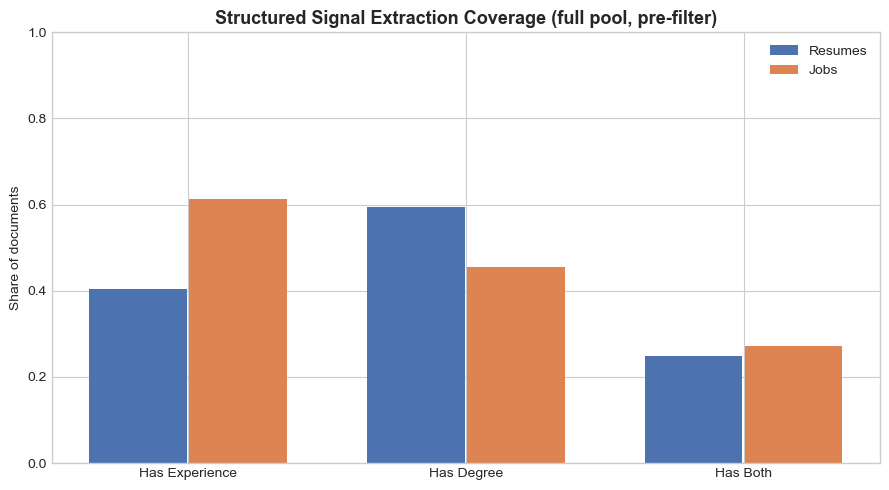

In [37]:
resume_vals = [resume_df["has_exp"].mean(), resume_df["has_degree"].mean(), resume_df["has_both"].mean()]
job_vals    = [job_df["has_exp"].mean(), job_df["has_degree"].mean(), job_df["has_both"].mean()]
labels = ["Has Experience", "Has Degree", "Has Both"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.18, resume_vals, 0.35, label="Resumes", color="#4C72B0")
ax.bar(x + 0.18, job_vals,    0.35, label="Jobs",    color="#DD8452")
ax.set_ylim(0, 1); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Share of documents")
ax.set_title("Structured Signal Extraction Coverage (full pool, pre-filter)", fontsize=13, fontweight="bold")
ax.legend()
fig.tight_layout()
plt.savefig(OUT_DIR / "01_extraction_coverage.png", dpi=150, bbox_inches="tight"); plt.show()

### 6.2 Job Title Distribution

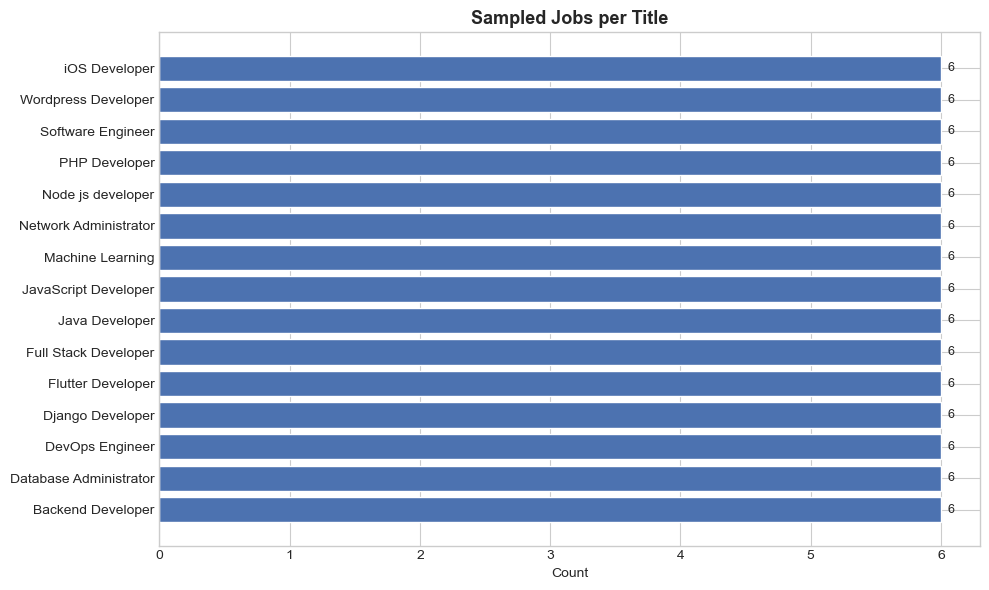

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
tc = job_sample["job_title"].value_counts().sort_values()
ax.barh(tc.index, tc.values, color="#4C72B0", edgecolor="white")
ax.set_title("Sampled Jobs per Title", fontsize=13, fontweight="bold")
ax.set_xlabel("Count")
for i, v in enumerate(tc.values): ax.text(v + 0.05, i, str(v), va="center", fontsize=9)
fig.tight_layout()
plt.savefig(OUT_DIR / "02_job_title_distribution.png", dpi=150, bbox_inches="tight"); plt.show()

### 6.3 Word Count Distributions

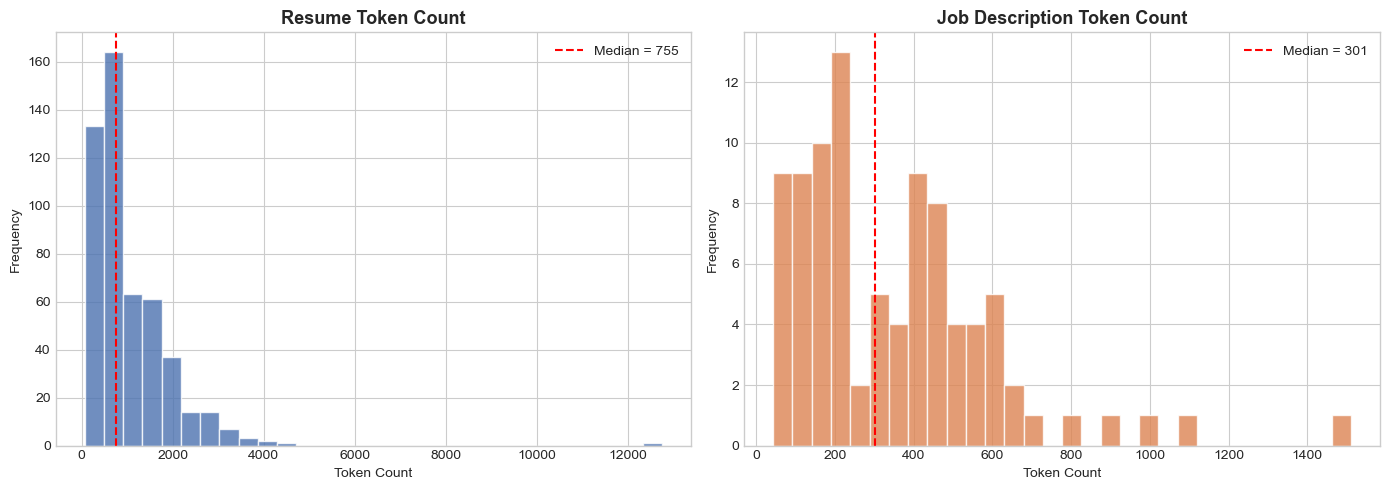

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (df, name, color) in enumerate([
    (resume_sample, "Resume", "#4C72B0"), (job_sample, "Job Description", "#DD8452")
]):
    axes[i].hist(df["word_count"], bins=30, color=color, edgecolor="white", alpha=0.8)
    med = df["word_count"].median()
    axes[i].axvline(med, color="red", linestyle="--", label=f"Median = {med:.0f}")
    axes[i].set_title(f"{name} Token Count", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Token Count"); axes[i].set_ylabel("Frequency"); axes[i].legend()
fig.tight_layout()
plt.savefig(OUT_DIR / "03_word_count_distributions.png", dpi=150, bbox_inches="tight"); plt.show()

### 6.4 Skills Analysis

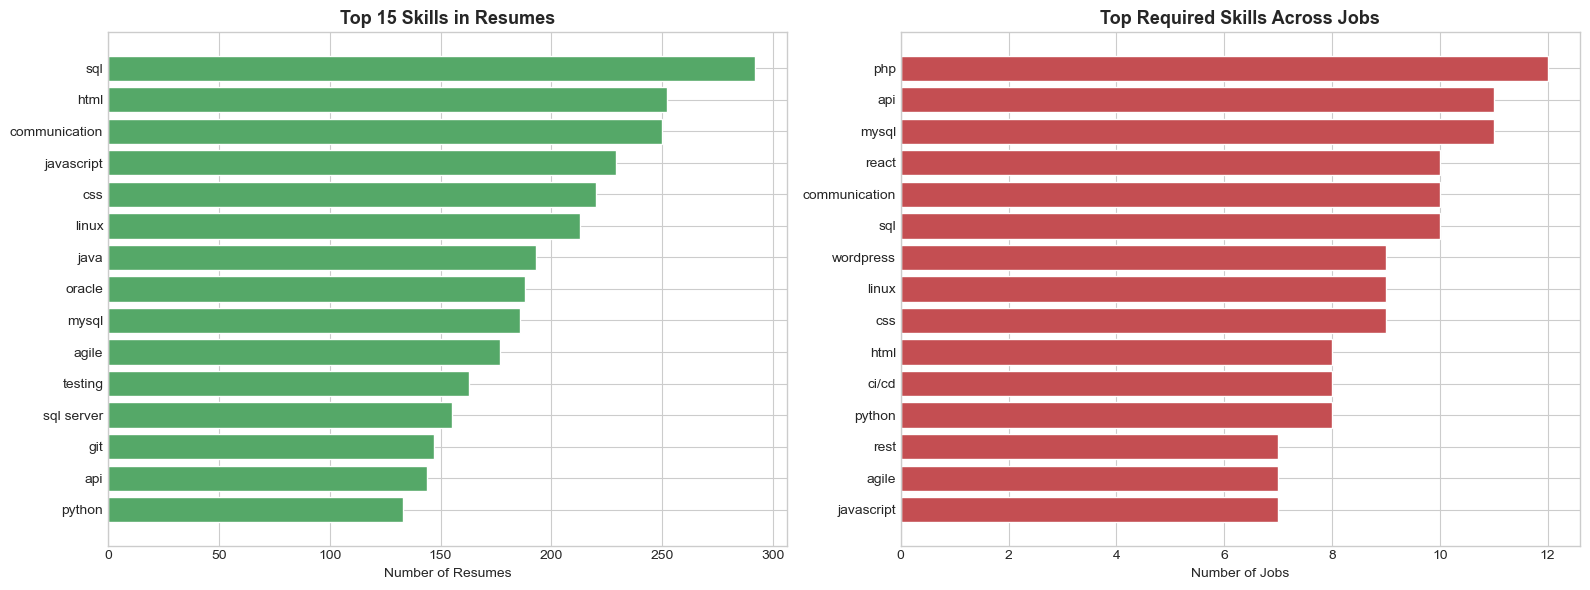

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rsc = pd.Series(Counter(s for ss in resume_sample["skill_set"] for s in ss)).sort_values(ascending=True).tail(15)
axes[0].barh(rsc.index, rsc.values, color="#55A868", edgecolor="white")
axes[0].set_title("Top 15 Skills in Resumes", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Resumes")

rqc = pd.Series(Counter(s for ss in job_sample["required_skills"] for s in ss)).sort_values(ascending=True).tail(15)
axes[1].barh(rqc.index, rqc.values, color="#C44E52", edgecolor="white")
axes[1].set_title("Top Required Skills Across Jobs", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Jobs")

fig.tight_layout()
plt.savefig(OUT_DIR / "04_skills_analysis.png", dpi=150, bbox_inches="tight"); plt.show()

### 6.5 Experience & Education Distributions (Observed Only)

These plots show **only the observed (non-imputed)** values to avoid artificial spikes from median imputation.

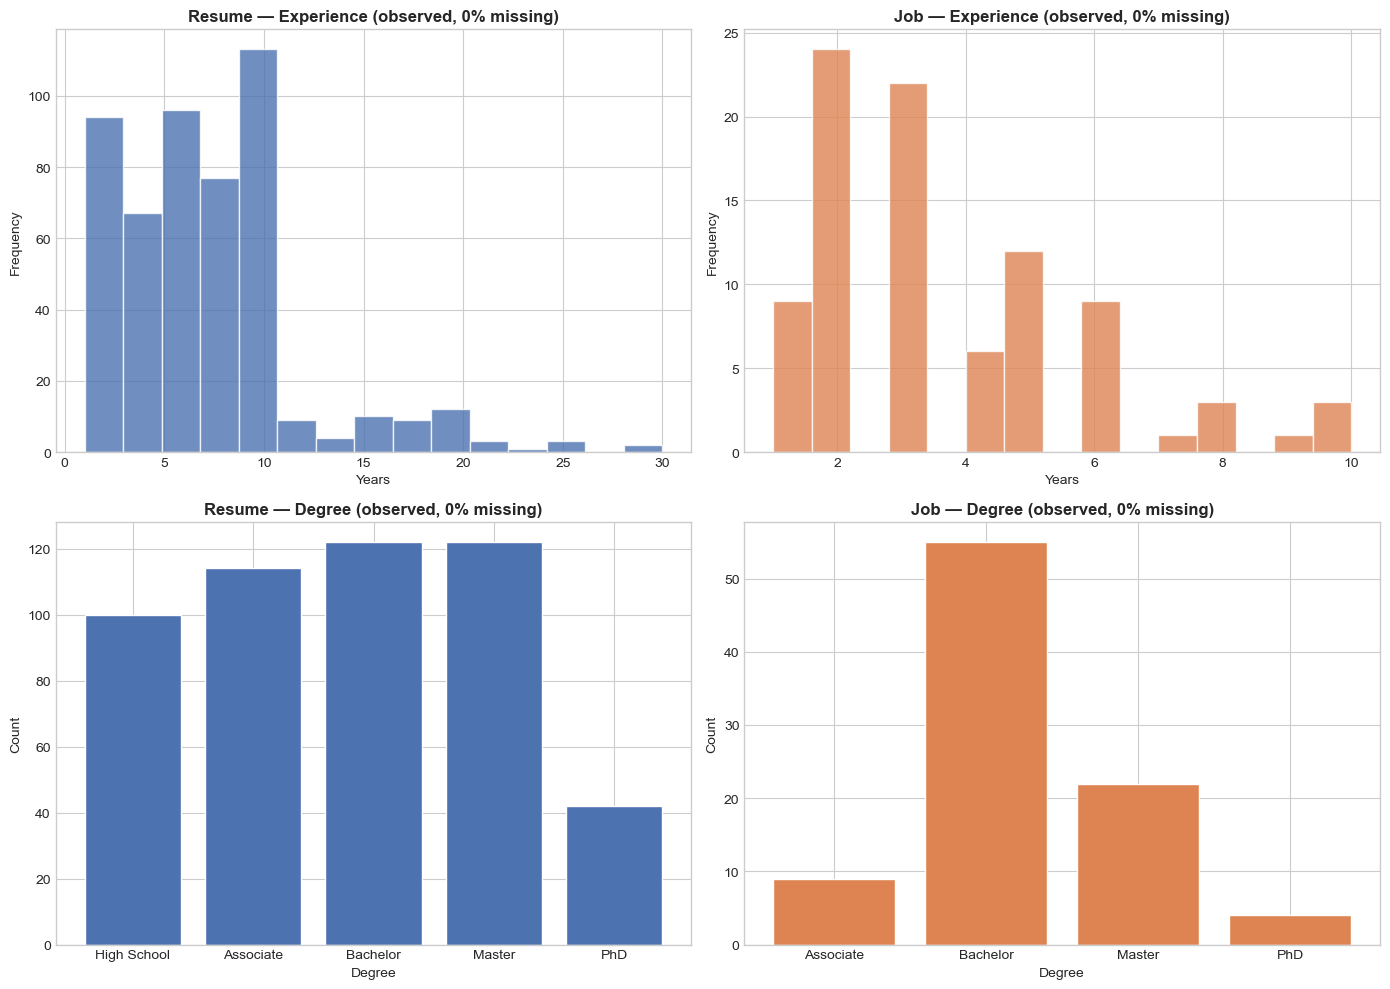

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
degree_labels = {1: "High School", 2: "Associate", 3: "Bachelor", 4: "Master", 5: "PhD"}

for i, (df, name, color) in enumerate([
    (resume_sample, "Resume", "#4C72B0"), (job_sample, "Job", "#DD8452")
]):
    obs = df["exp_years_raw"].dropna()
    miss = df["exp_years_raw"].isna().mean()
    axes[0, i].hist(obs, bins=15, color=color, edgecolor="white", alpha=0.8)
    axes[0, i].set_title(f"{name} — Experience (observed, {miss:.0%} missing)", fontsize=12, fontweight="bold")
    axes[0, i].set_xlabel("Years"); axes[0, i].set_ylabel("Frequency")

for i, (df, name, color) in enumerate([
    (resume_sample, "Resume", "#4C72B0"), (job_sample, "Job", "#DD8452")
]):
    obs = df["degree_level_raw"].dropna().astype(int).value_counts().sort_index()
    miss = df["degree_level_raw"].isna().mean()
    labs = [degree_labels.get(int(k), str(k)) for k in obs.index]
    axes[1, i].bar(labs, obs.values, color=color, edgecolor="white")
    axes[1, i].set_title(f"{name} — Degree (observed, {miss:.0%} missing)", fontsize=12, fontweight="bold")
    axes[1, i].set_xlabel("Degree"); axes[1, i].set_ylabel("Count")

fig.tight_layout()
plt.savefig(OUT_DIR / "05_experience_education.png", dpi=150, bbox_inches="tight"); plt.show()

### 6.6 Redundancy Threshold Sweep

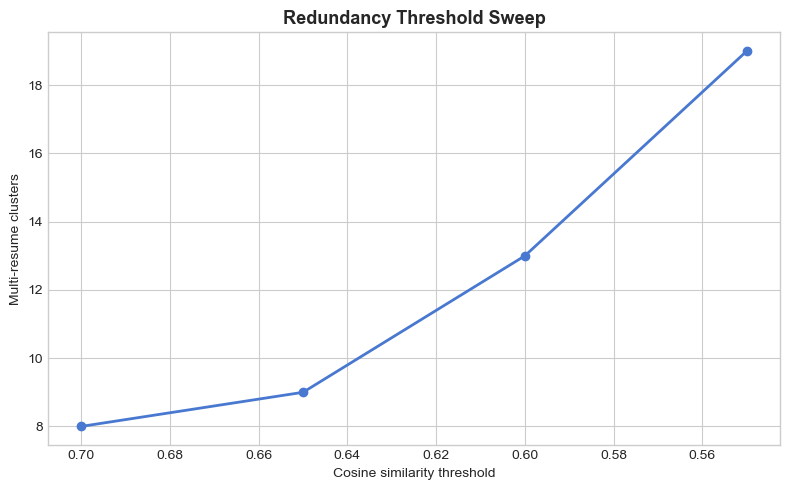

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_sweep["threshold"], threshold_sweep["multi_resume"], marker="o", linewidth=2)
ax.invert_xaxis()
ax.set_xlabel("Cosine similarity threshold")
ax.set_ylabel("Multi-resume clusters")
ax.set_title("Redundancy Threshold Sweep", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig(OUT_DIR / "06_redundancy_sweep.png", dpi=150, bbox_inches="tight"); plt.show()

### 6.7 Redundancy Cluster Sizes (Chosen Threshold)

19:29:27  INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:29:27  INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


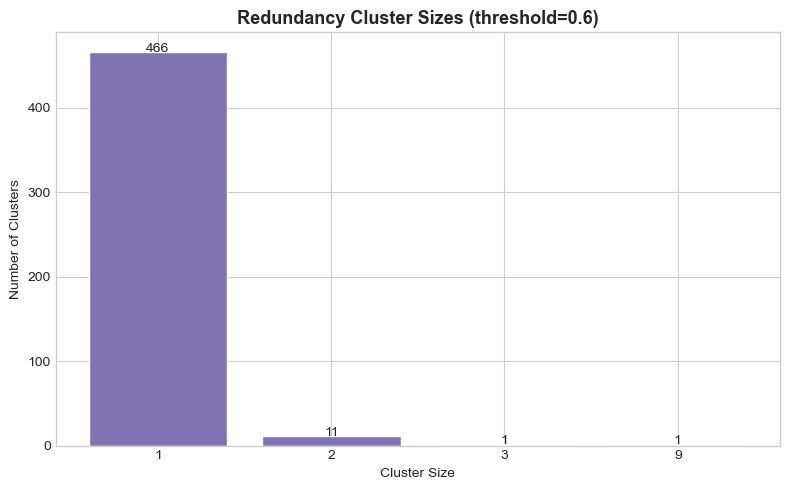

In [49]:
cs = resume_sample["redundancy_cluster"].value_counts().value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cs.index.astype(str), cs.values, color="#8172B2", edgecolor="white")
ax.set_title(f"Redundancy Cluster Sizes (threshold={REDUNDANCY_THRESHOLD_CHOSEN})", fontsize=13, fontweight="bold")
ax.set_xlabel("Cluster Size"); ax.set_ylabel("Number of Clusters")
for i, v in enumerate(cs.values): ax.text(i, v + 0.3, str(v), ha="center", fontsize=10)
fig.tight_layout()
plt.savefig(OUT_DIR / "07_redundancy_clusters.png", dpi=150, bbox_inches="tight"); plt.show()

## 7. Save Processed Data

We save:
1. **Full cleaned datasets** with extraction signals (for re-sampling)
2. **MILP-ready resume & job samples** with all engineered features
3. **`pair_features.csv`** — the key Notebook 1→2 interface. Contains all raw scoring signals per (resume, job) pair. Notebook 2 loads this and applies tuneable weights:
   ```python
   score = W_TFIDF * tfidf_sim + W_BM25 * bm25_sim + W_SKILL * skill_jaccard
           - W_EXP * exp_gap - W_DEG * degree_gap - W_LENGTH * length_penalty
   ```
4. **Threshold sweep** results

In [51]:
def serialise_for_csv(df):
    """Convert list/dict columns to JSON strings for CSV storage."""
    out = df.copy()
    for col in out.columns:
        out[col] = out[col].apply(lambda v: json.dumps(v) if isinstance(v, (list, dict, set, tuple)) else v)
    return out

print("Saving outputs …")

# Full cleaned datasets (for re-sampling if needed)
serialise_for_csv(resume_df).to_csv(DATA_DIR / "resumes_full_cleaned.csv", index=False)
serialise_for_csv(job_df).to_csv(DATA_DIR / "jobs_full_cleaned.csv", index=False)

# MILP-ready samples with all engineered features
serialise_for_csv(resume_sample).to_csv(DATA_DIR / "resumes_milp_sample.csv", index=False)
serialise_for_csv(job_sample).to_csv(DATA_DIR / "jobs_milp_sample.csv", index=False)

# Pair feature table — the key interface for Notebook 2
pair_df.to_csv(DATA_DIR / "pair_features.csv", index=False)

# Metadata
threshold_sweep.to_csv(DATA_DIR / "redundancy_threshold_sweep.csv", index=False)

print()
for f in sorted(DATA_DIR.glob("*.csv")):
    print(f"  {f.name:45s} {f.stat().st_size / 1024:8.0f} KB")

Saving outputs …

  job_title_des.csv                                 4488 KB
  jobs_full_cleaned.csv                            12090 KB
  jobs_milp_sample.csv                               647 KB
  pair_features.csv                                 6636 KB
  redundancy_threshold_sweep.csv                       0 KB
  Resume.csv                                       54954 KB
  resume_txt_combined.csv                         204113 KB
  resumes_full_cleaned.csv                        528914 KB
  resumes_milp_sample.csv                          10179 KB
  UpdatedResumeDataSet.csv                          3034 KB


## 8. Parameter Summary & Justifications

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `MIN_WORDS` | 30 | Documents below this lack sufficient content for NLP |
| `FILTER_MODE` | `"both"` | Only keep documents with *both* experience and degree signals — avoids noisy imputation |
| `N_RESUME_SAMPLE` | 500 | 500 × 90 = 45,000 binary MILP variables — tractable for Gurobi |
| `N_JOB_SAMPLE` | 90 | ~6 per title across 15 titles |
| `MAX_RESUMES_PER_STRATUM` | 35 | Stratified by (exp_band × degree_band) to ensure representative coverage |
| Tokeniser | NLTK `word_tokenize` | Penn Treebank–style; linguistically aware |
| Lemmatiser | `WordNetLemmatizer` + POS | Reduces vocabulary; protects short acronyms |
| `SKILLS_DICT` | ~108 + lemma variants | Boundary-aware regex for *all* skills (not just short ones) |
| `TOP_K_REQUIRED` | 5 | Top-5 distinctive skills per job by IDF |
| `SKILL_SCARCITY_BOOST` | 1.0 | Required skills rarer in candidate pool get higher weight |
| `REDUNDANCY_THRESHOLD` | 0.60 | Chosen via sweep; produces meaningful multi-resume clusters |
| `REVIEW_TIME_SAFETY_MULTIPLIER` | 1.15 | Conservative buffer on estimated review time |
| Experience extraction | Regex + word-number | ~40–60% recall; filter-then-sample avoids imputation dominance |
| Degree extraction | Boundary-aware regex | Avoids 'scrum master' → Master's false positives |
| BM25 engine | k1=1.5, b=0.75 | Standard Okapi BM25 parameters; pre-fitted for Notebook 2 |
| `RANDOM_SEED` | 42 | Reproducibility |

### References
- Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval*. Cambridge University Press.
- Broder, A. Z. (1997). "On the Resemblance and Containment of Documents." *Compression and Complexity of Sequences*, IEEE.
- Robertson, S., & Zaragoza, H. (2009). "The Probabilistic Relevance Framework: BM25 and Beyond." *Foundations and Trends in IR*.

---

**Next → Notebook 2**: Composite scoring (TF-IDF + BM25 + skill overlap + experience gap + degree gap), MILP formulation with Gurobi, greedy baseline, results comparison, and sensitivity analysis.